In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
print('Өгөгдлийн хэлбэр:', df.shape)
print()
print('Статистик утгууд:')
df.describe()

Өгөгдлийн хэлбэр: (768, 9)

Статистик утгууд:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [3]:
print(df.isnull().sum())

cols_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_check:
    print(f'  {col}: {(df[col] == 0).sum()}')

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
  Glucose: 5
  BloodPressure: 35
  SkinThickness: 227
  Insulin: 374
  BMI: 11


In [5]:
corr_matrix = df.corr()
outcome_corr = corr_matrix['Outcome'].drop('Outcome').abs().sort_values(ascending=False)
print('Outcome-тай корреляц (абсолют утгаар):')
print(outcome_corr)

top5_features = outcome_corr.head(5).index.tolist()

print( top5_features)

Outcome-тай корреляц (абсолют утгаар):
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64
['Glucose', 'BMI', 'Age', 'Pregnancies', 'DiabetesPedigreeFunction']


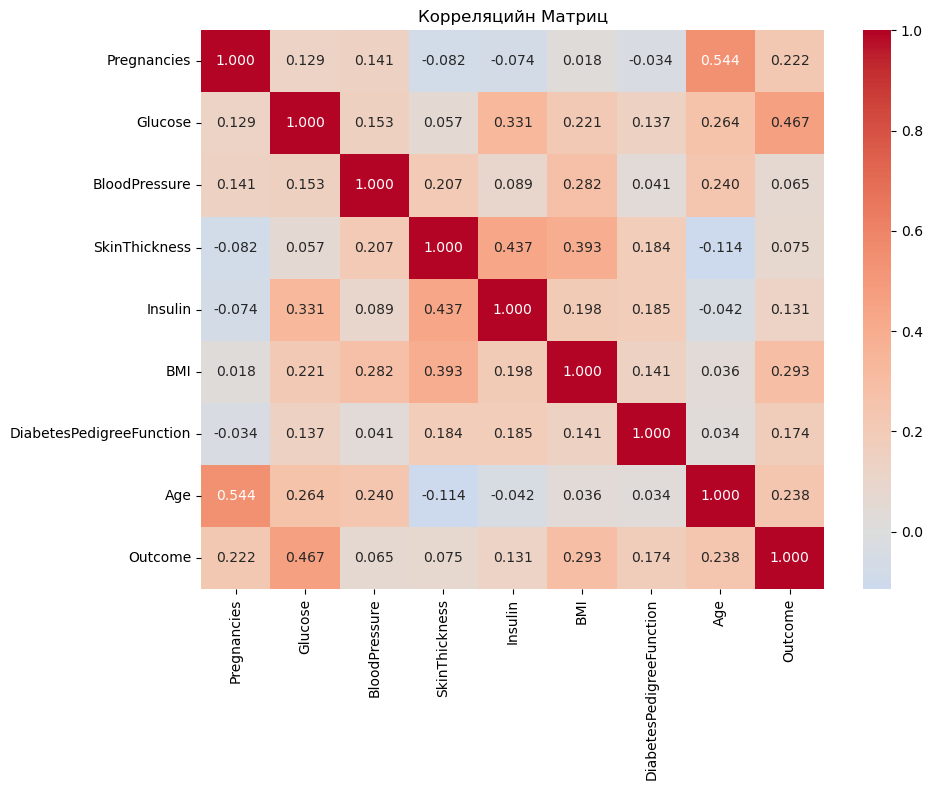

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Корреляцийн Матриц')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = df.columns.drop('Outcome').tolist()

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print('Нормчилсний дараах эхний 5 бичлэг:')
df_scaled.head()

Нормчилсний дараах эхний 5 бичлэг:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.352941,0.743719,0.590164,0.353535,0.000000,0.500745,0.234415,0.483333,1
1,0.058824,0.427136,0.540984,0.292929,0.000000,0.396423,0.116567,0.166667,0
2,0.470588,0.919598,0.524590,0.000000,0.000000,0.347243,0.253629,0.183333,1
3,0.058824,0.447236,0.540984,0.232323,0.111111,0.418778,0.038002,0.000000,0
4,0.000000,0.688442,0.327869,0.353535,0.198582,0.642325,0.943638,0.200000,1


  Outlier тоо: 5


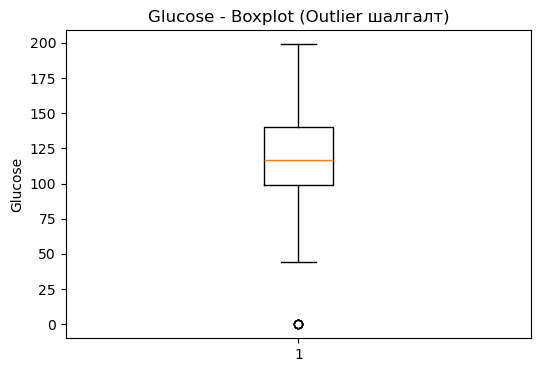

In [12]:
outlier_col = 'Glucose'

Q1 = df[outlier_col].quantile(0.25)
Q3 = df[outlier_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[outlier_col] < lower_bound) | (df[outlier_col] > upper_bound)]
print(f'  Outlier тоо: {len(outliers)}')

plt.figure(figsize=(6, 4))
plt.boxplot(df[outlier_col], vert=True)
plt.title(f'{outlier_col} - Boxplot (Outlier шалгалт)')
plt.ylabel(outlier_col)
plt.show()

In [15]:
df_clean = df[(df[outlier_col] >= lower_bound) & (df[outlier_col] <= upper_bound)].copy()
print(f'Outlier устгахаас өмнө: {len(df)}')
print(f'Outlier устгасны дараа: {len(df_clean)}')
df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])
df_clean.reset_index(drop=True, inplace=True)

Outlier устгахаас өмнө: 768
Outlier устгасны дараа: 763


In [16]:
corr_clean = df_clean.corr()
top5 = corr_clean['Outcome'].drop('Outcome').abs().sort_values(ascending=False).head(5).index.tolist()
print(top5)

X = df_clean[top5].values
Y = df_clean['Outcome'].values

print(f'X хэлбэр: {X.shape}')
print(f'Y хэлбэр: {Y.shape}')

['Glucose', 'BMI', 'Age', 'Pregnancies', 'DiabetesPedigreeFunction']
X хэлбэр: (763, 5)
Y хэлбэр: (763,)


In [17]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.33, random_state=42)

print(xtrain.shape)
print(xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(511, 5)
(252, 5)
(511,)
(252,)


In [19]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/351.2 MB 1.6 MB/s eta 0:03:43
   ---------------------------------------- 1.0/351.2 MB 1.6 MB/s eta 0:03:33
   ---------------------------------------- 1.6/351.2 MB 1.7 MB/s eta 0:03:23
   ---------------------------------------- 1.8/351.2 MB 1.8 MB/s eta 0:03:19
   ---------------------------------------- 2.4/351.2 MB 1.8 MB/s eta 0:03:12
   ---------------------------------------- 2.9/351.2 MB 1.9 MB/s eta 0:03:04
   ---------------------------------------- 3.4/351.2 MB 1.9 MB/s eta 0:03:01
   ---------------------------------------- 3.7/351.2 MB 2.0 MB/s eta 0:02:58
   ---------------------------------------- 4.2/351.2 MB 2.0 MB/s eta 0:02:55
    --------------------------------------- 4.5/351.2 MB 2.0 MB/s eta 0:02:55
    ---

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann = Sequential([
    Dense(units=24, activation='relu', input_dim=5),   
    Dense(units=24, activation='relu'),                 
    Dense(units=1,  activation='sigmoid')              
])

ann.compile(
    optimizer='adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann.summary()

C:\Users\Gateway\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
hist = ann.fit(
    xtrain, ytrain,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.4093 - loss: 0.6952 - val_accuracy: 0.6796 - val_loss: 0.6900
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6544 - loss: 0.6875 - val_accuracy: 0.6990 - val_loss: 0.6789
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6324 - loss: 0.6805 - val_accuracy: 0.6990 - val_loss: 0.6700
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6324 - loss: 0.6743 - val_accuracy: 0.6990 - val_loss: 0.6626
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6324 - loss: 0.6693 - val_accuracy: 0.6990 - val_loss: 0.6556
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6324 - loss: 0.6648 - val_accuracy: 0.6990 - val_loss: 0.6488
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6324 - loss: 0.6604 - val_accuracy: 0.6990 - val_loss: 0.6427
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6324 - loss: 0.6552 - val_accuracy: 0.

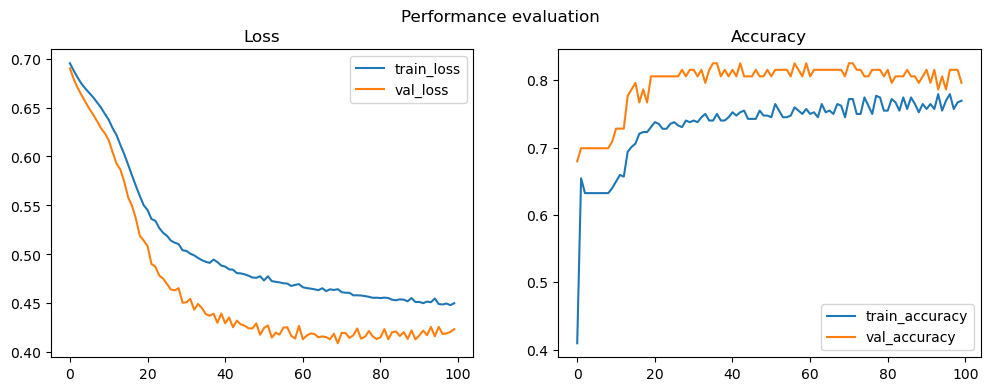

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.plot(hist.history['loss'], label='train_loss')
plt.plot(hist.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.suptitle('Performance evaluation')


plt.subplot(122)
plt.plot(hist.history['accuracy'], label='train_accuracy')
plt.plot(hist.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy')
plt.legend()

plt.show()

In [23]:
Y_pred = ann.predict(xtest)
Y_pred = [1 if y >= 0.5 else 0 for y in Y_pred]
print(Y_pred)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
[1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1]


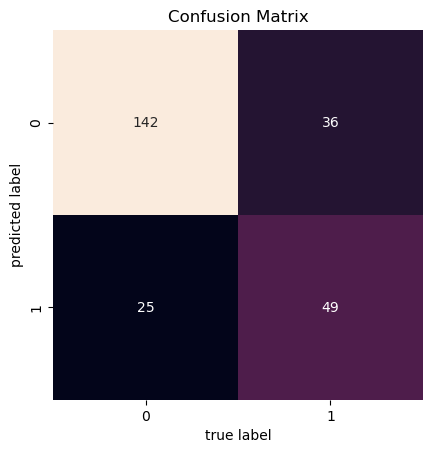

In [24]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(ytest, Y_pred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.title('Confusion Matrix')
plt.show()

In [25]:
score = ann.evaluate(xtest, ytest, verbose=0)
print('Test loss:    ', score[0])
print('Test accuracy:', score[1])

Test loss:     0.4879826605319977
Test accuracy: 0.7579365372657776
